In [1]:
from nwb_utils import NWBUtils
from optogenetics_utils import create_opto_data_frame, find_unique_combinations,find_unique_stimulation,create_opto_data_frame_combined,load_opto_data_frame,find_unique_values_by_conditions

In [2]:
combined_dataframe=create_opto_data_frame_combined(save_path='/root/capsule/results/combined_opto_data_frame.csv')

Processing NWB files:   0%|          | 0/57 [00:00<?, ?file/s]

Found behavior NWB: /root/capsule/data/optogenetics_nwb/778147_2025-04-08_16-06-29.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/778147_2025-04-08_16-06-29.nwb
Found behavior NWB: /root/capsule/data/optogenetics_nwb/778147_2025-04-09_11-05-31.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/778147_2025-04-09_11-05-31.nwb


In [ ]:
find_unique_stimulation(combined_dataframe_original)

In [ ]:
find_unique_stimulation(combined_dataframe)

In [ ]:
find_unique_stimulation(combined_dataframe,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation','laser_1_target_areas','laser_2_target_areas'
    ])

In [ ]:
conds = {"laser_start": "Go cue", "laser_end": "Trial start"}
unique_vals = find_unique_values_by_conditions(combined_dataframe, conds, output_column="session")
print(unique_vals)

In [ ]:
nwb_path="/root/capsule/data/optogenetics_nwb/789197_2025-08-05_10-49-42.nwb"

nwb_data=NWBUtils.read_behavior_nwb(nwb_full_path=nwb_path)

In [9]:
conditions

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,laser_pulse_duration,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,n_trials
0,1,473.0,Both,50.0,Trial start,0.0,Go cue,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,600
1,1,473.0,Both,1.0,Trial start,0.0,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,495
2,1,473.0,Both,3.0,Go cue,0.0,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,452
3,1,473.0,Both,3.0,Go cue,0.3,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,427
4,1,473.0,Both,1.0,Trial start,0.0,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left MD,right MD,272
5,1,473.0,Both,3.0,Go cue,0.3,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left MD,right MD,261
6,1,473.0,Both,50.0,Trial start,0.0,Go cue,0.0,Sine,40.0,0.002,off,0.5,on,on,left MD,right MD,234
7,1,473.0,Both,3.0,Go cue,0.0,NA,0.0,Sine,40.0,0.002,off,0.5,on,on,left MD,right MD,230
8,1,473.0,Both,3.0,Go cue,0.0,Trial start,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,123
9,1,473.0,Both,3.0,Go cue,0.3,Trial start,0.0,Sine,40.0,0.002,off,0.5,on,on,left ALM,right ALM,120


In [12]:
import pandas as pd
conditions=find_unique_stimulation(combined_dataframe,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation','laser_1_target_areas','laser_2_target_areas'
    ])

# pick a row (e.g., the most frequent combo)
row = conditions.iloc[1]

# turn it into a criteria dict
criteria = (
    row.drop(labels=['n_trials'], errors='ignore')
       .where(pd.notna(row), None)         # pd.NA/NaN -> None
       .to_dict()
)

criteria


{'laser_on_trial': '1',
 'laser_wavelength': '473.0',
 'laser_location': 'Both',
 'laser_duration': '1.0',
 'laser_start': 'Trial start',
 'laser_start_offset': '0.0',
 'laser_end': 'NA',
 'laser_end_offset': '0.0',
 'laser_protocol': 'Sine',
 'laser_frequency': '40.0',
 'laser_pulse_duration': '0.002',
 'session_wide_control': 'off',
 'fraction_of_session': '0.5',
 'session_start_with': 'on',
 'session_alternation': 'on',
 'laser_1_target_areas': 'left ALM',
 'laser_2_target_areas': 'right ALM'}

In [ ]:
find_unique_values_by_conditions(df=combined_dataframe,conditions=criteria,output_column='session')

{'stay': <Figure size 600x450 with 1 Axes>,
 'switch': <Figure size 600x450 with 1 Axes>,
 'win_stay': <Figure size 600x450 with 1 Axes>,
 'lose_switch': <Figure size 600x450 with 1 Axes>,
 'response': <Figure size 600x450 with 1 Axes>}

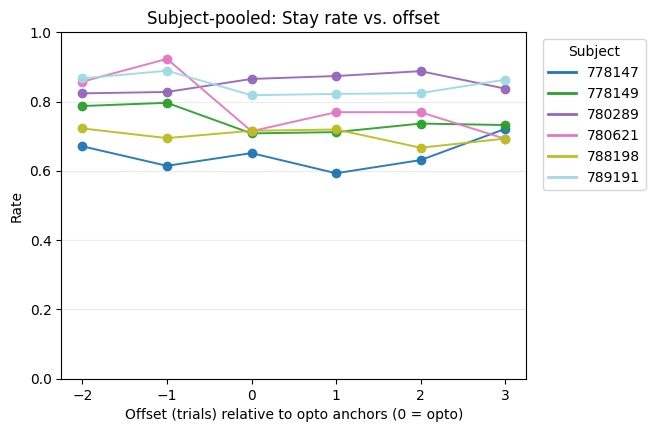

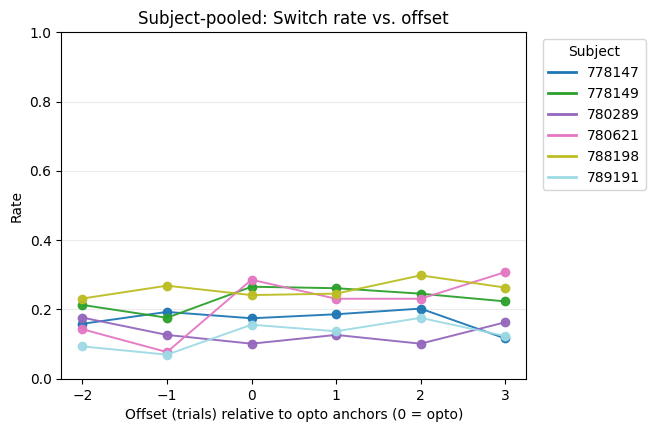

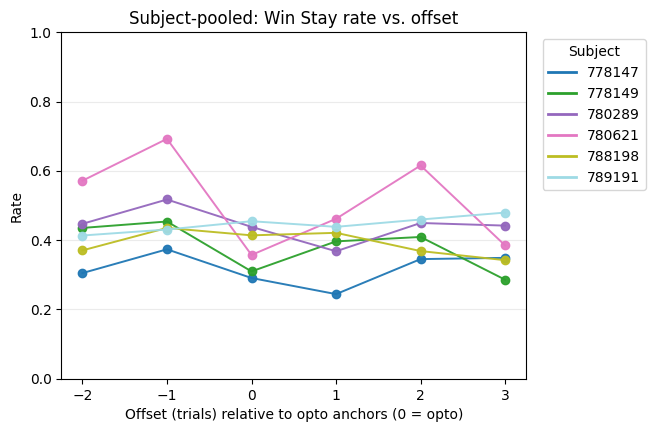

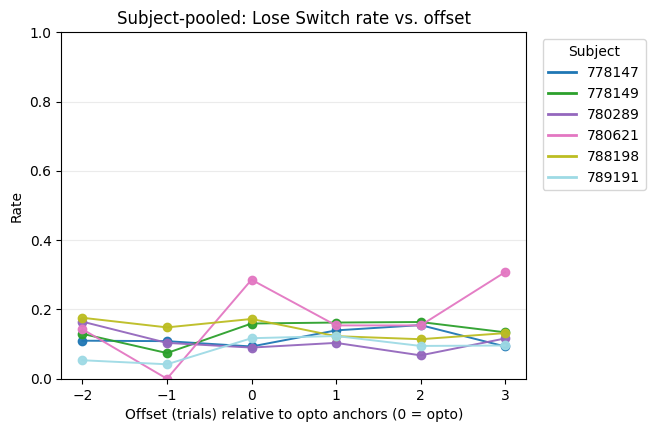

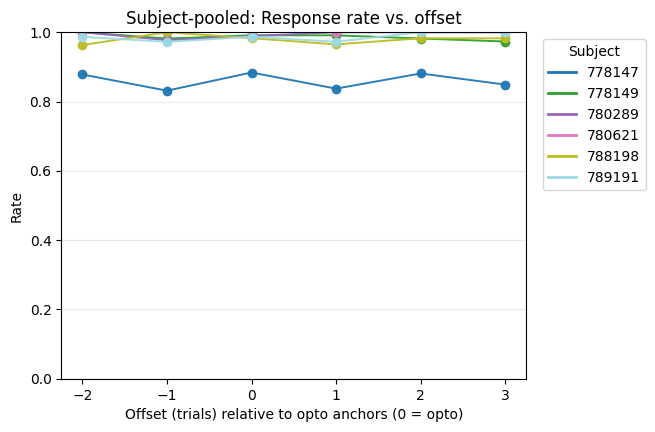

In [13]:
# visualization
from nwb_utils import NWBUtils
from optogenetics_utils import create_opto_data_frame, find_unique_combinations,find_unique_stimulation,create_opto_data_frame_combined,load_opto_data_frame,find_unique_values_by_conditions
from optogenetics_visualization import plot_stay_switch_over_window
combined_dataframe=load_opto_data_frame()
plot_stay_switch_over_window(combined_dataframe,criteria = criteria,window=(-2,3),line_by='subject')